In [1]:
# import of all that is needed

# visualization / analytics
import pandas as pd
import matplotlib as plt
from src.evaluation.plots import plot_demand_vs_order

# environment
from src.envs.inventory_env import SimpleInventoryEnv
from src.envs.multi_echelon import MultiEchelonInventoryEnv

# baselines
from src.baselines.base_stock import base_stock_policy
from src.baselines.sS_policy import sS_policy

# experimentation
from src.evaluation.run_episode import run_episode
from src.evaluation.experiment import run_policy_experiment

# RL
from src.rl.train_ppo import train_ppo, ppo_policy

In [2]:
def make_random_policy(
    env_class=SimpleInventoryEnv,
    include_demand_in_state=False,
    normalize_action_space=False,
):
    env_for_sampling = env_class(
        include_demand_in_state=include_demand_in_state,
        normalize_action_space=normalize_action_space,
    )

    def policy(obs, info):
        return env_for_sampling.action_space.sample()

    return policy


def run_experiment(
    scenario_id,
    seed,
    stability_lambda,
    holding_cost_rate,
    stockout_cost_rate,
    env_class=SimpleInventoryEnv,
    include_demand_in_state=False,
    normalize_action_space=False,
    ppo_model=None,
):
    experiments = [
        (
            "random",
            make_random_policy(
                env_class=env_class,
                include_demand_in_state=include_demand_in_state,
                normalize_action_space=normalize_action_space,
            ),
        ),
        ("base_stock", base_stock_policy(S=50)),
        ("sS", sS_policy(s=20, S=50)),
    ]

    if ppo_model is not None:
        experiments.append(("ppo", ppo_policy(ppo_model)))

    all_metrics = []
    trajectories = {}

    for policy_name, policy_fn in experiments:
        df, metrics = run_policy_experiment(
            policy_name=policy_name,
            policy_fn=policy_fn,
            seed=seed,
            scenario_id=scenario_id,
            env_class=env_class,
            stability_lambda=stability_lambda,
            holding_cost_rate=holding_cost_rate,
            stockout_cost_rate=stockout_cost_rate,
            include_demand_in_state=include_demand_in_state,
            normalize_action_space=normalize_action_space,
        )

        all_metrics.append(metrics)
        trajectories[policy_name] = df

    results = pd.DataFrame(all_metrics)

    return results, trajectories

In [3]:
ppo_model_v3 = train_ppo(
    env_class=SimpleInventoryEnv,
    stability_lambda=0.05,
    holding_cost_rate=0.5,
    stockout_cost_rate=10.0,
    include_demand_in_state=False,
    normalize_action_space=False,
)

ppo_model_v4 = train_ppo(
    env_class=SimpleInventoryEnv,
    stability_lambda=0.05,
    holding_cost_rate=0.5,
    stockout_cost_rate=20.0,
    include_demand_in_state=False,
    normalize_action_space=False,
)

ppo_model_v5 = train_ppo(
    env_class=SimpleInventoryEnv,
    stability_lambda=0.05,
    holding_cost_rate=0.5,
    stockout_cost_rate=20.0,
    include_demand_in_state=True,
    normalize_action_space=False,
)

ppo_model_v6 = train_ppo(
    env_class=SimpleInventoryEnv,
    stability_lambda=0.05,
    holding_cost_rate=0.5,
    stockout_cost_rate=20.0,
    include_demand_in_state=True,
    normalize_action_space=True,
)

ppo_model_multi = train_ppo(
    env_class=MultiEchelonInventoryEnv,
    stability_lambda=0.05,
    holding_cost_rate=0.5,
    stockout_cost_rate=20.0,
    include_demand_in_state=True,
    normalize_action_space=True,
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 50        |
|    ep_rew_mean     | -8.78e+03 |
| time/              |           |
|    fps             | 10393     |
|    iterations      | 1         |
|    time_elapsed    | 0         |
|    total_timesteps | 2048      |
----------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 50            |
|    ep_rew_mean          | -8.65e+03     |
| time/                   |               |
|    fps                  | 5376          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00053039246 |
|    clip_fraction        | 0.00083       |
|    clip_range           | 

In [4]:
from src.envs.inventory_env import SimpleInventoryEnv
from src.envs.multi_echelon import MultiEchelonInventoryEnv

all_results = []
all_trajectories = {}

scenarios = [
    # ---- single-echelon development history ----
    {
        "scenario_id": "v1_cost_only",
        "env_class": SimpleInventoryEnv,
        "stability_lambda": 0.0,
        "holding_cost_rate": 0.5,
        "stockout_cost_rate": 2.0,
        "include_demand_in_state": False,
        "normalize_action_space": False,
        "ppo_model": None,
    },
    {
        "scenario_id": "v2_stability_penalty_lambda1",
        "env_class": SimpleInventoryEnv,
        "stability_lambda": 1.0,
        "holding_cost_rate": 0.5,
        "stockout_cost_rate": 2.0,
        "include_demand_in_state": False,
        "normalize_action_space": False,
        "ppo_model": None,
    },
    {
        "scenario_id": "v3_lambda005_stockout10",
        "env_class": SimpleInventoryEnv,
        "stability_lambda": 0.05,
        "holding_cost_rate": 0.5,
        "stockout_cost_rate": 10.0,
        "include_demand_in_state": False,
        "normalize_action_space": False,
        "ppo_model": ppo_model_v3,
    },
    {
        "scenario_id": "v4_unmet_demand_penalty",
        "env_class": SimpleInventoryEnv,
        "stability_lambda": 0.05,
        "holding_cost_rate": 0.5,
        "stockout_cost_rate": 20.0,
        "include_demand_in_state": False,
        "normalize_action_space": False,
        "ppo_model": ppo_model_v4,
    },
    {
        "scenario_id": "v5_state_with_demand",
        "env_class": SimpleInventoryEnv,
        "stability_lambda": 0.05,
        "holding_cost_rate": 0.5,
        "stockout_cost_rate": 100.0,
        "include_demand_in_state": True,
        "normalize_action_space": False,
        "ppo_model": ppo_model_v5,
    },
    {
        "scenario_id": "v6_normalized_action_space",
        "env_class": SimpleInventoryEnv,
        "stability_lambda": 0.05,
        "holding_cost_rate": 0.5,
        "stockout_cost_rate": 100.0,
        "include_demand_in_state": True,
        "normalize_action_space": True,
        "ppo_model": ppo_model_v6,
    },

    # ---- final multi-echelon experiment ----
    {
        "scenario_id": "final_multi_echelon_baselines",
        "env_class": MultiEchelonInventoryEnv,
        "stability_lambda": 0.05,
        "holding_cost_rate": 0.5,
        "stockout_cost_rate": 100.0,
        "include_demand_in_state": True,
        "normalize_action_space": False,
        "ppo_model": None,
    },
    {
        "scenario_id": "final_multi_echelon_ppo_stockout_20",
        "env_class": MultiEchelonInventoryEnv,
        "stability_lambda": 0.05,
        "holding_cost_rate": 0.5,
        "stockout_cost_rate": 20.0,
        "include_demand_in_state": True,
        "normalize_action_space": True,
        "ppo_model": ppo_model_multi,
    },
    {
        "scenario_id": "final_multi_echelon_ppo_stockout_100",
        "env_class": MultiEchelonInventoryEnv,
        "stability_lambda": 0.05,
        "holding_cost_rate": 0.5,
        "stockout_cost_rate": 100.0,
        "include_demand_in_state": True,
        "normalize_action_space": True,  # PPO uses normalized action space
        "ppo_model": ppo_model_multi,
    },
]

for cfg in scenarios:
    results, trajectories = run_experiment(
        scenario_id=cfg["scenario_id"],
        seed=42,
        env_class=cfg["env_class"],
        stability_lambda=cfg["stability_lambda"],
        holding_cost_rate=cfg["holding_cost_rate"],
        stockout_cost_rate=cfg["stockout_cost_rate"],
        include_demand_in_state=cfg["include_demand_in_state"],
        normalize_action_space=cfg["normalize_action_space"],
        ppo_model=cfg["ppo_model"],
    )

    all_results.append(results)
    all_trajectories[cfg["scenario_id"]] = trajectories

final_results = pd.concat(all_results, ignore_index=True)

In [5]:
final_results

,policy,scenario_id,stability_lambda,bwe,order_variance,demand_variance,total_reward,total_holding_cost,total_stockout_cost,total_stability_penalty,avg_inventory,service_level,holding_cost_rate,stockout_cost_rate,total_demand,total_unmet_demand,include_demand_in_state,normalize_action_space
0,random,v1_cost_only,0.00,6.116490,183.966541,30.077143,-9769.137146,9673.137146,16.000000,0.000000,386.925486,0.984934,0.5,2.0,531.0,8.000000,False,False
1,base_stock,v1_cost_only,0.00,1.688841,50.795510,30.077143,-1084.500000,988.500000,16.000000,0.000000,39.540000,0.984934,0.5,2.0,531.0,8.000000,False,False
2,sS,v1_cost_only,0.00,9.438057,283.869796,30.077143,-1113.500000,705.500000,68.000000,0.000000,28.220000,0.935970,0.5,2.0,531.0,34.000000,False,False
3,random,v2_stability_penalty_lambda1,1.00,7.295628,219.431641,30.077143,-10980.160162,10085.732260,16.000000,798.427902,403.429290,0.984934,0.5,2.0,531.0,8.000000,False,False
4,base_stock,v2_stability_penalty_lambda1,1.00,1.688841,50.795510,30.077143,-1487.500000,988.500000,16.000000,403.000000,39.540000,0.984934,0.5,2.0,531.0,8.000000,False,False
5,sS,v2_stability_penalty_lambda1,1.00,9.438057,283.869796,30.077143,-2139.500000,705.500000,68.000000,1026.000000,28.220000,0.935970,0.5,2.0,531.0,34.000000,False,False
6,random,v3_lambda005_stockout10,0.05,7.927374,238.432772,30.077143,-10345.117316,10139.419640,80.000000,45.697677,405.576786,0.984934,0.5,10.0,531.0,8.000000,False,False
7,base_stock,v3_lambda005_stockout10,0.05,1.688841,50.795510,30.077143,-1168.650000,988.500000,80.000000,20.150000,39.540000,0.984934,0.5,10.0,531.0,8.000000,False,False
8,sS,v3_lambda005_stockout10,0.05,9.438057,283.869796,30.077143,-1436.800000,705.500000,340.000000,51.300000,28.220000,0.935970,0.5,10.0,531.0,34.000000,False,False
9,ppo,v3_lambda005_stockout10,0.05,0.000279,0.008380,30.077143,-10298.860583,4.734852,5147.027037,0.071657,0.189394,0.030692,0.5,10.0,531.0,514.702704,False,False


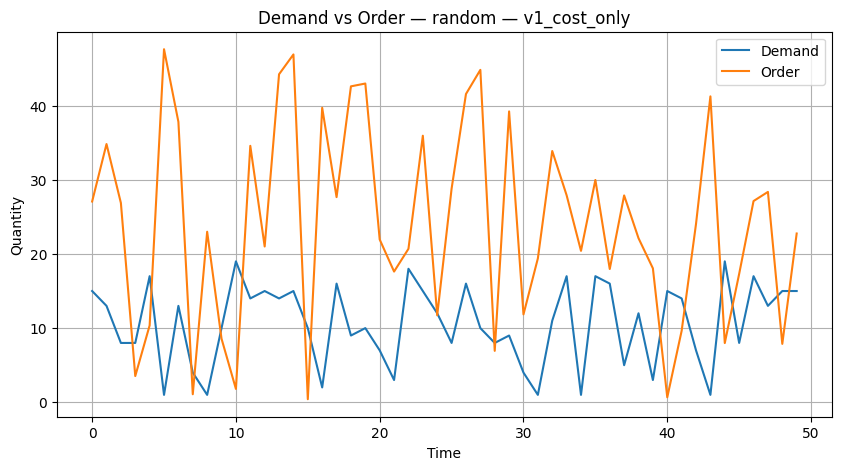

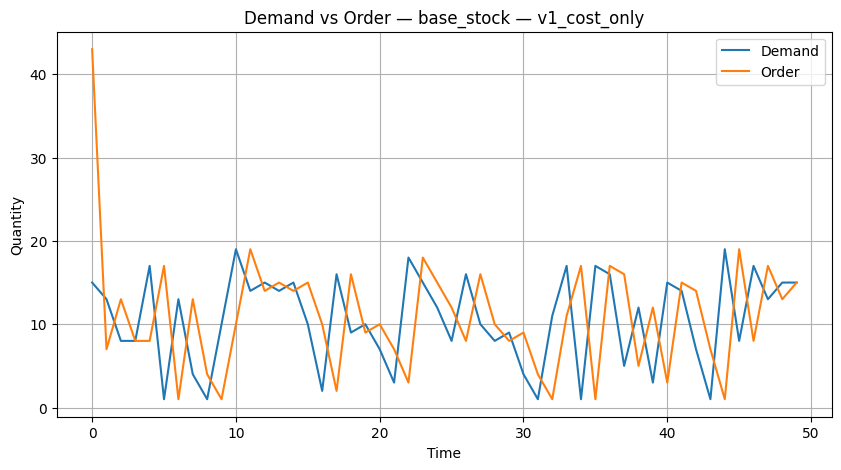

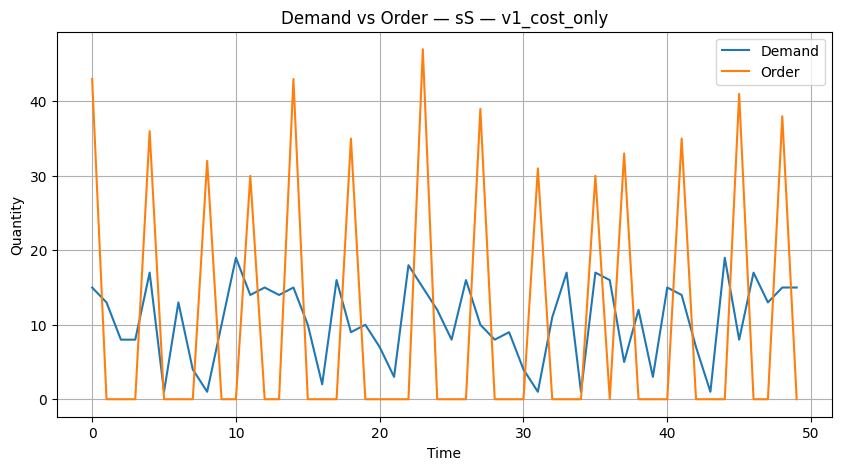

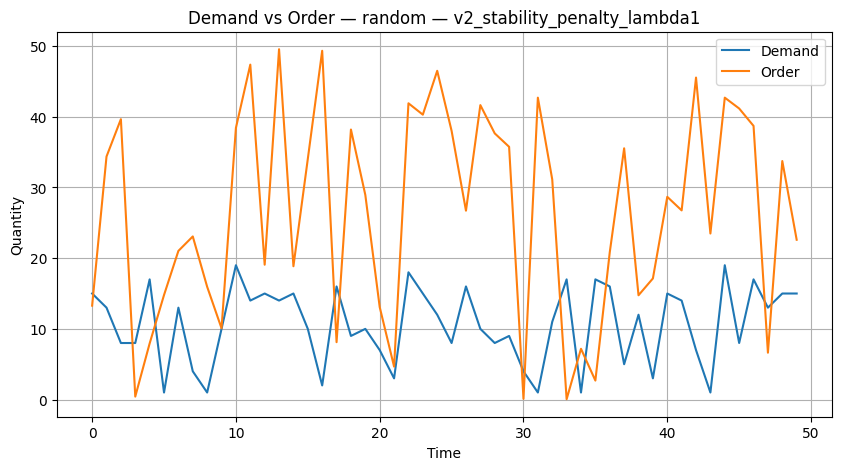

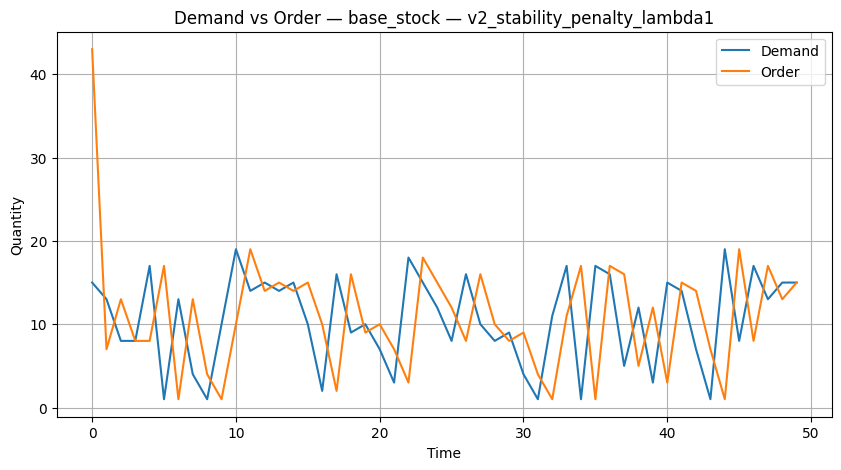

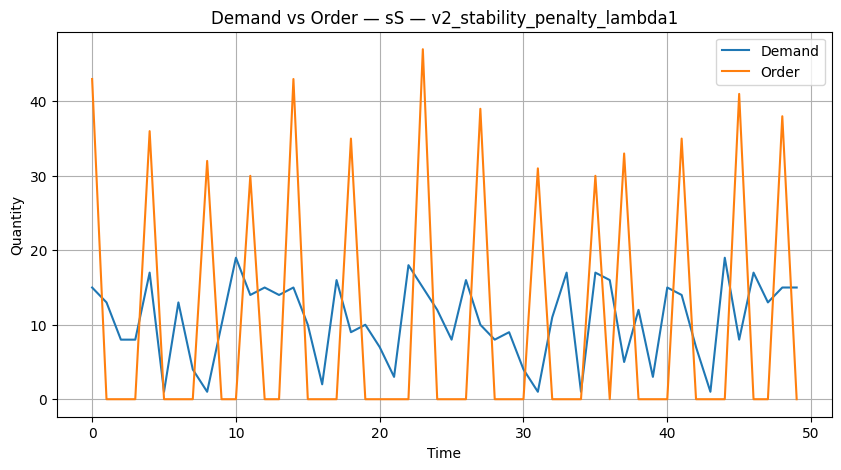

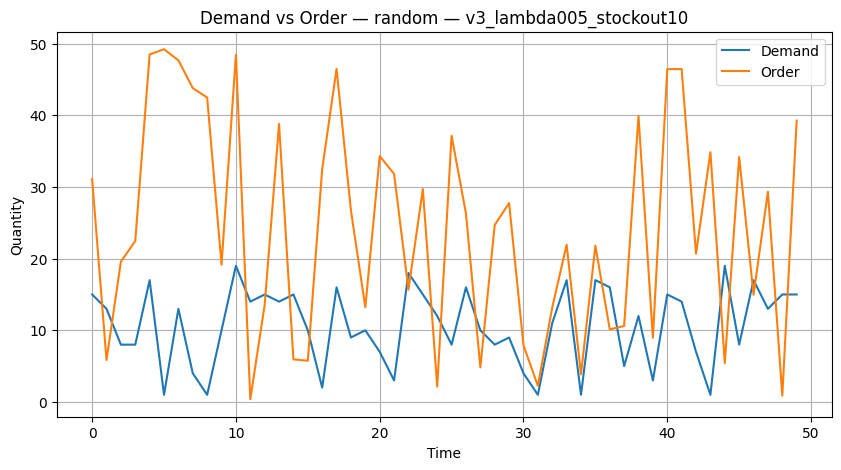

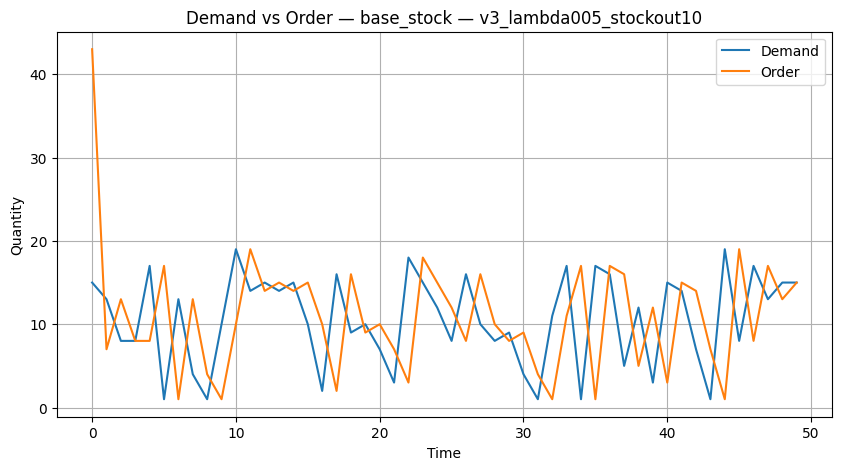

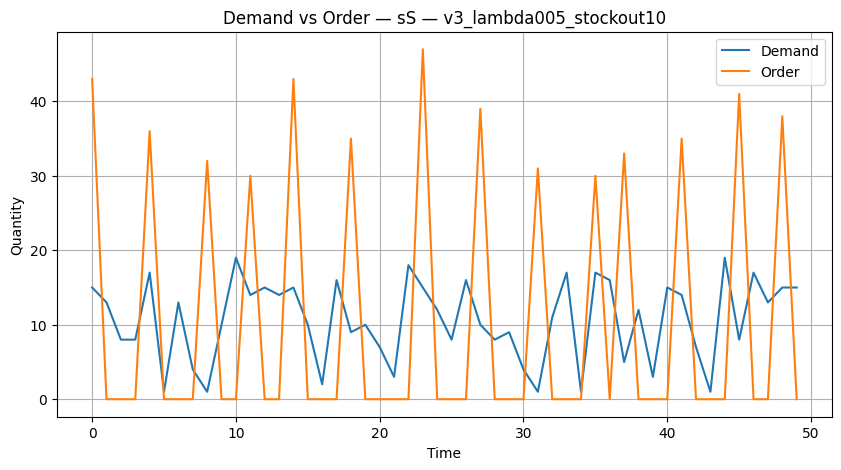

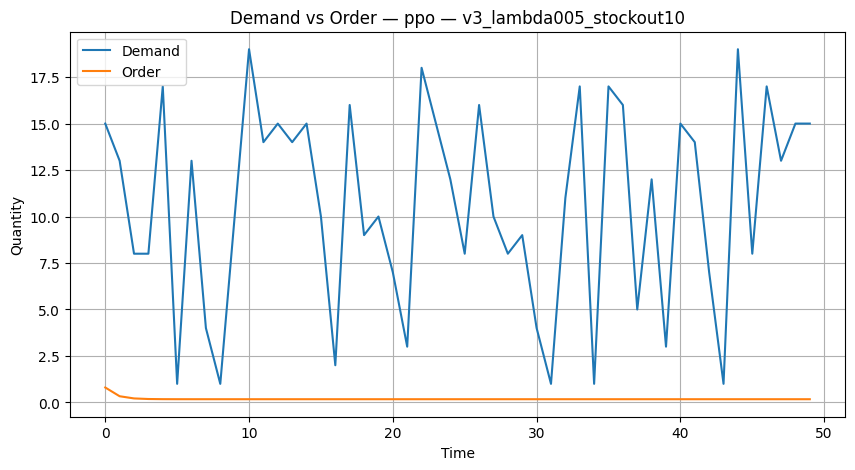

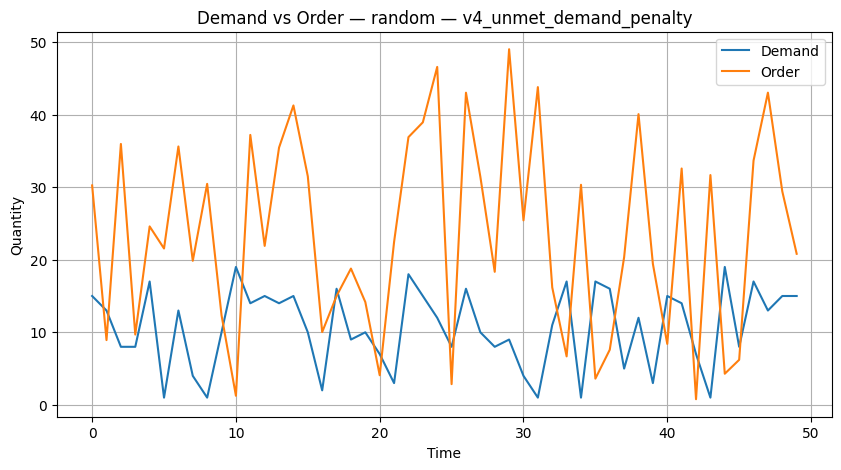

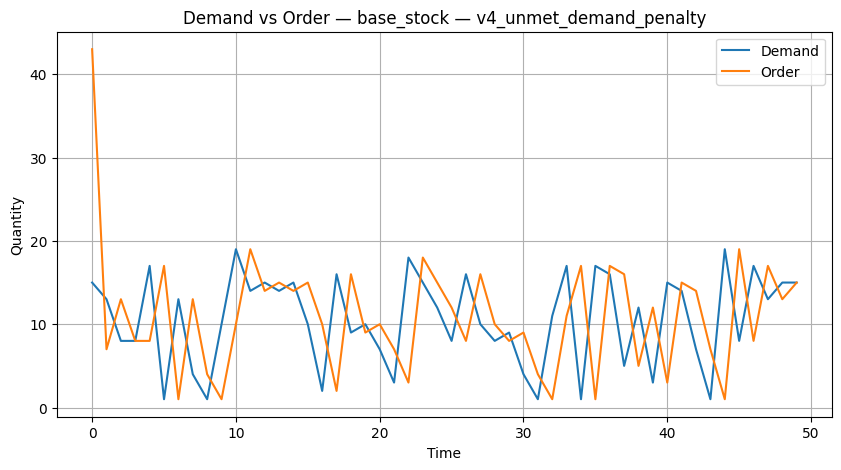

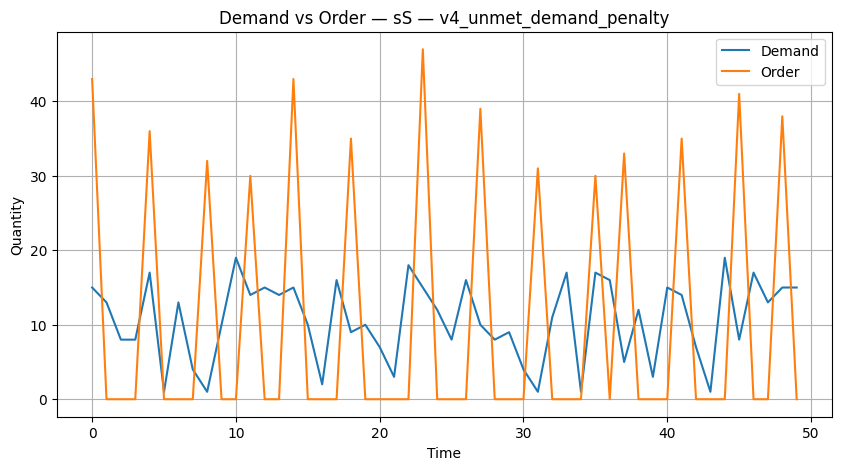

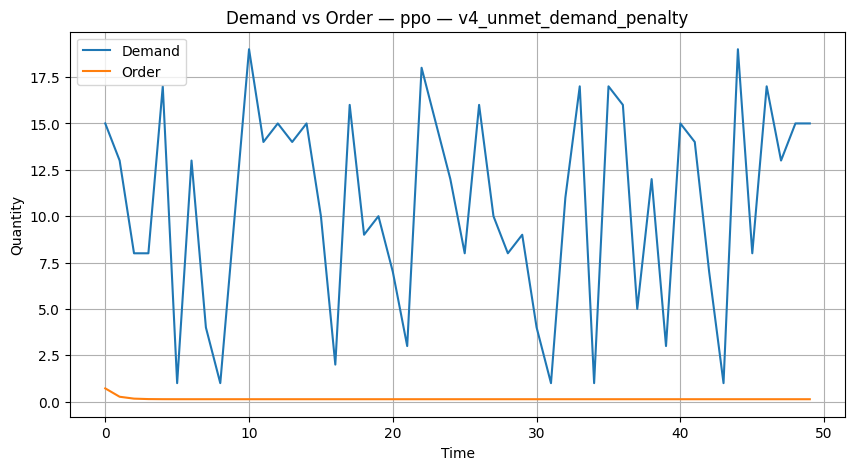

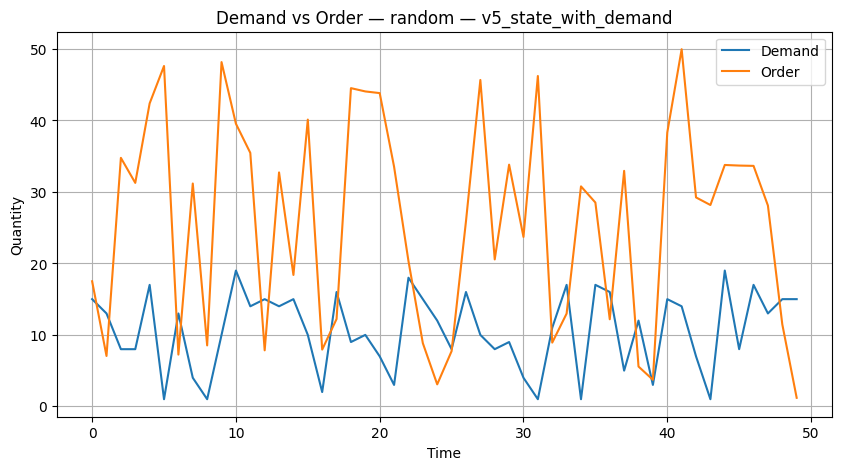

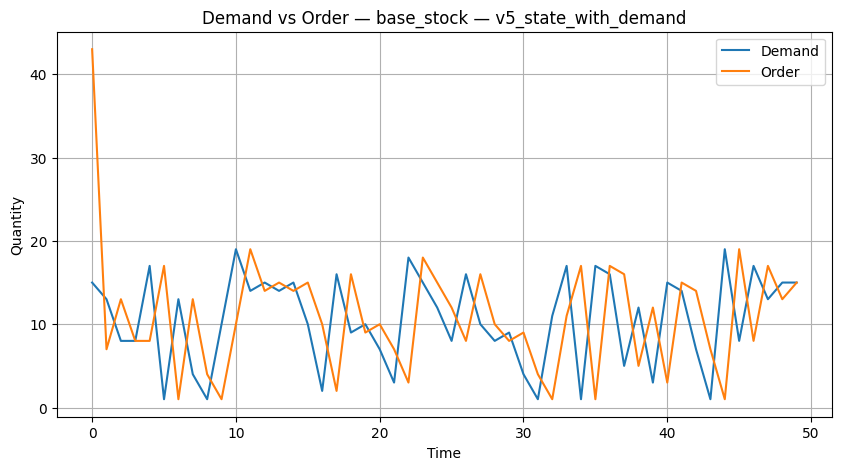

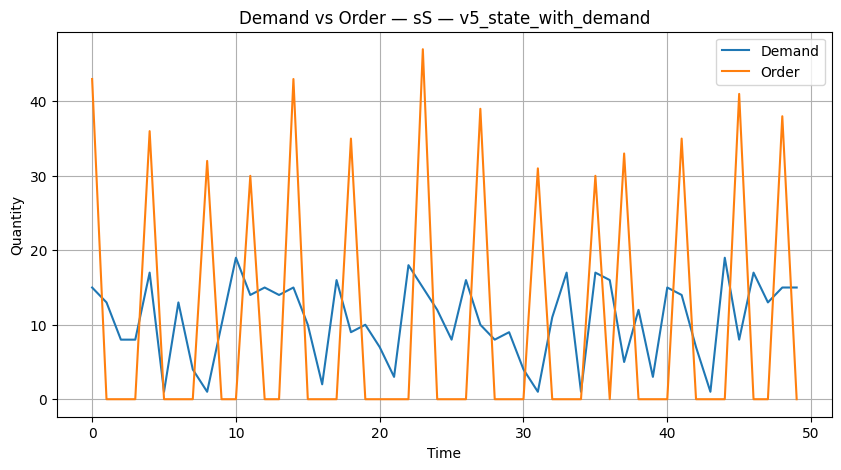

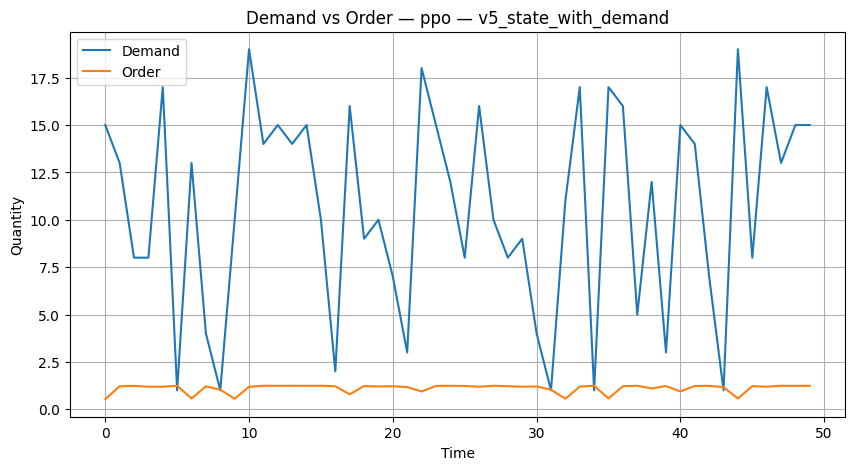

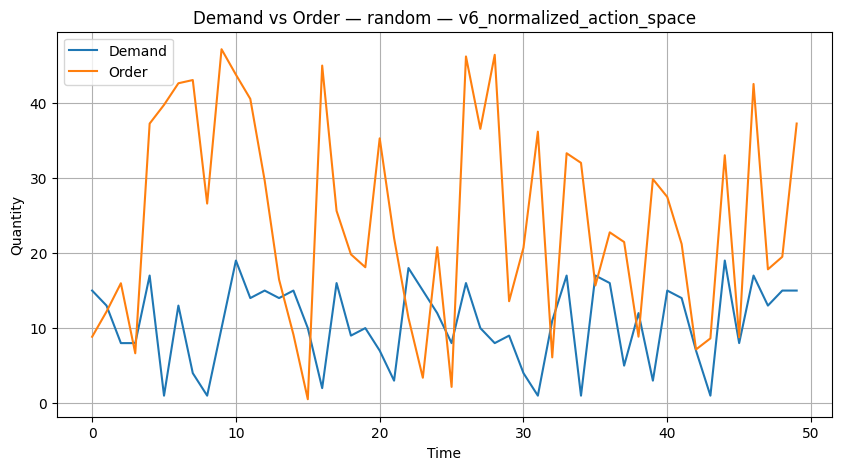

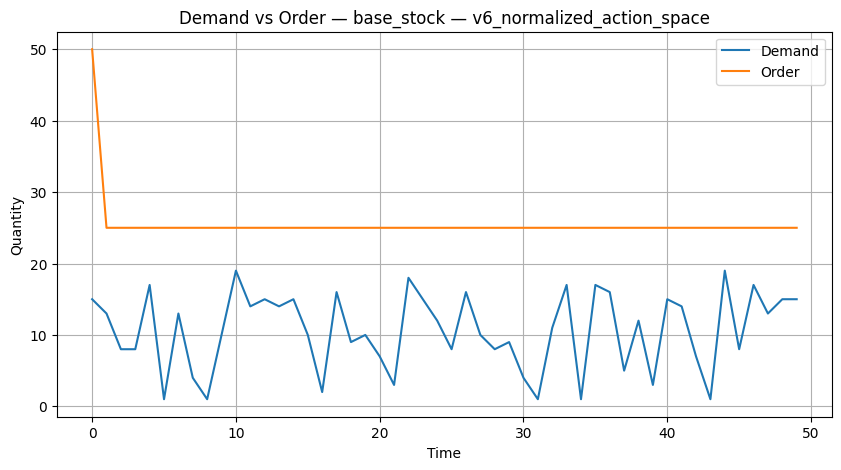

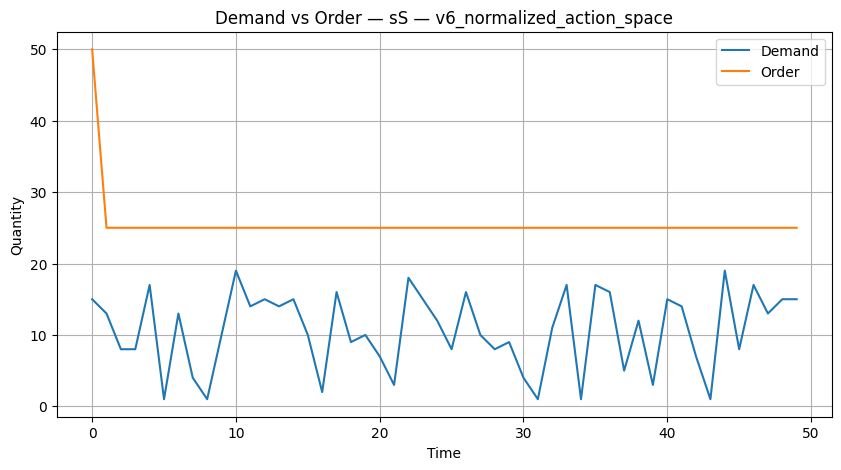

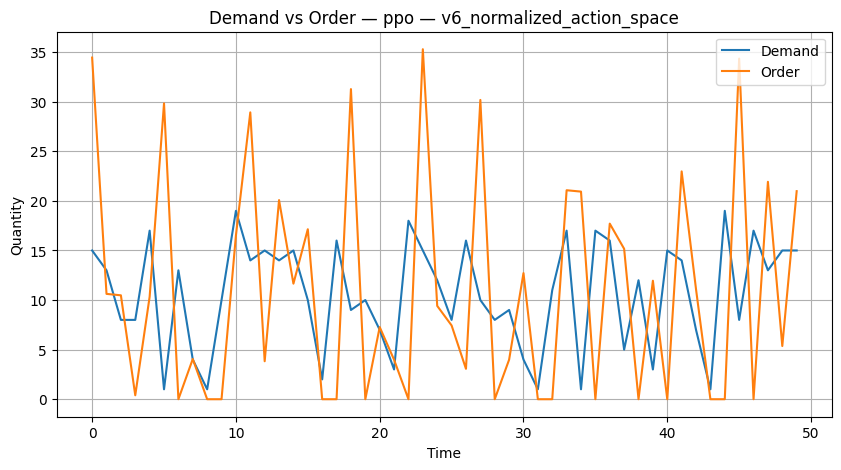

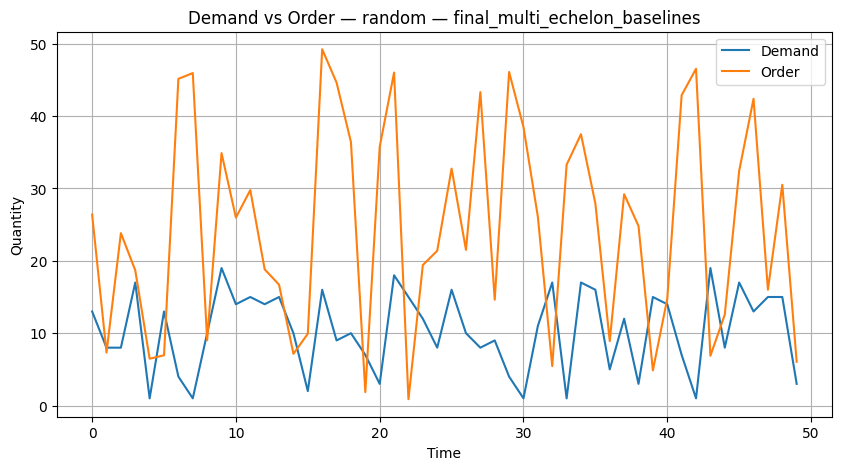

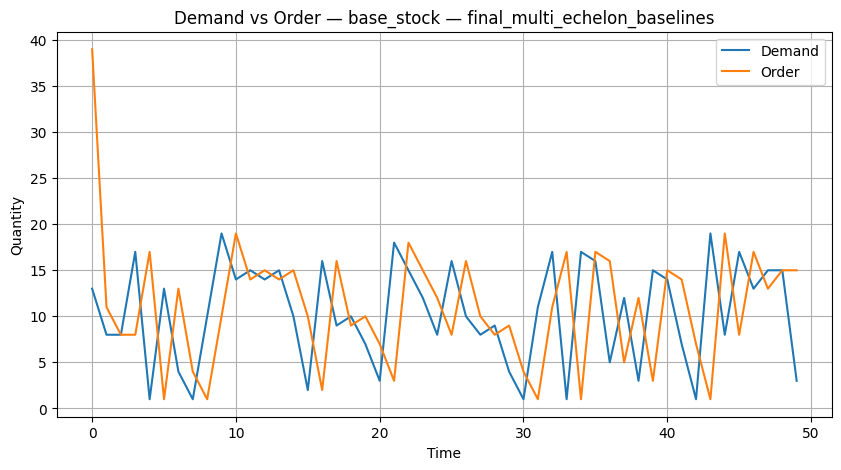

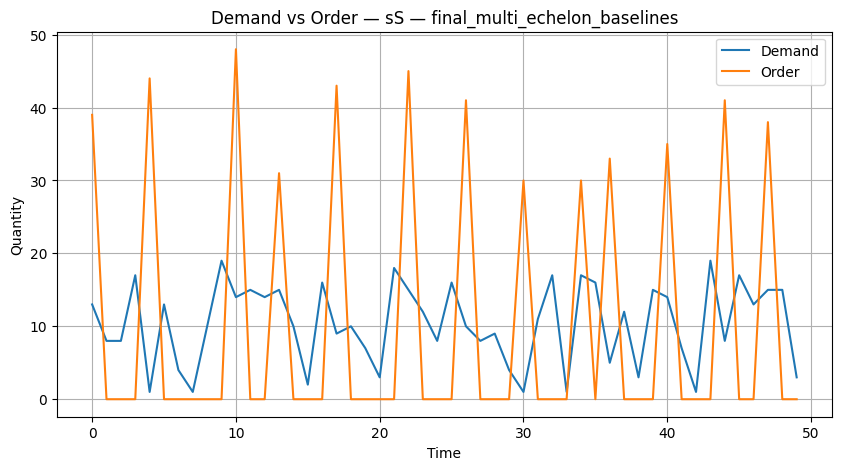

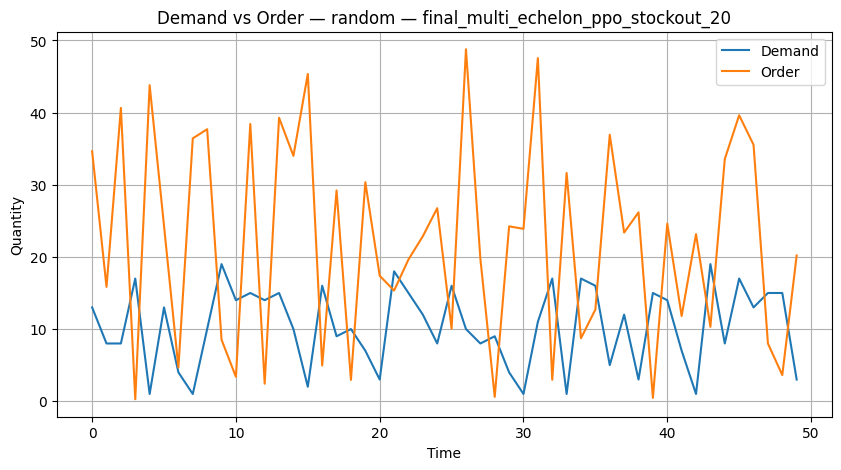

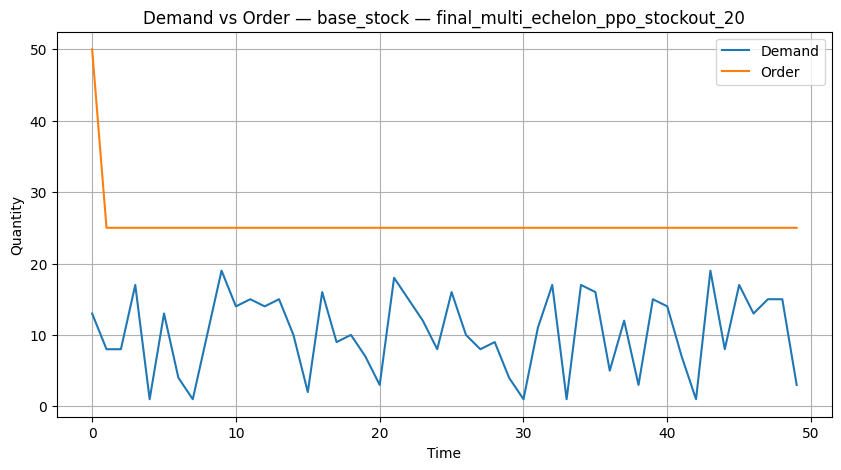

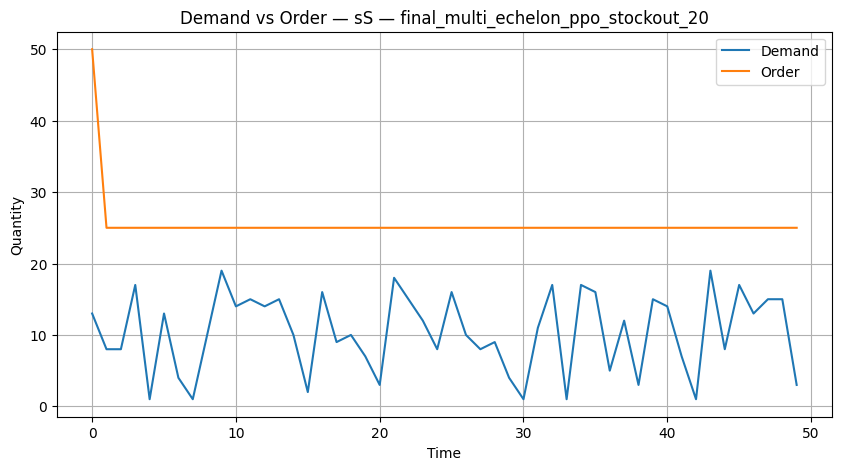

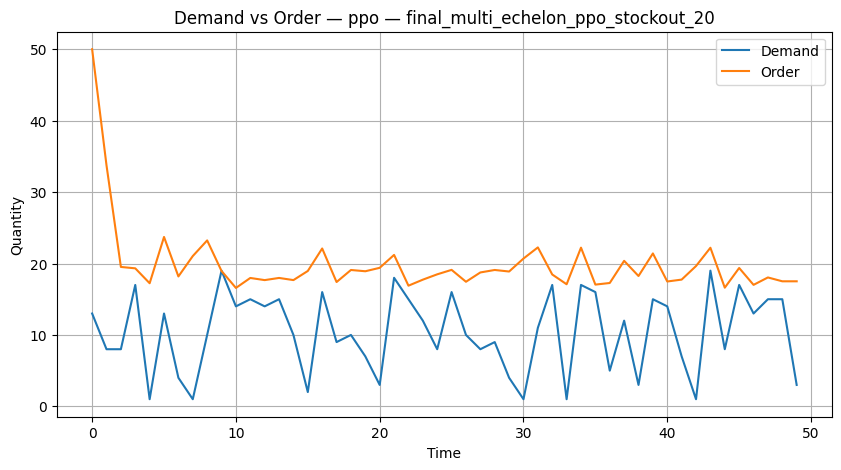

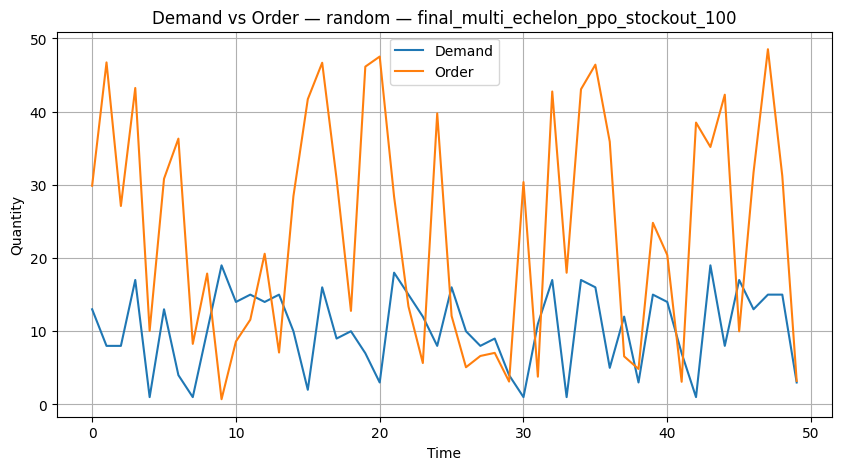

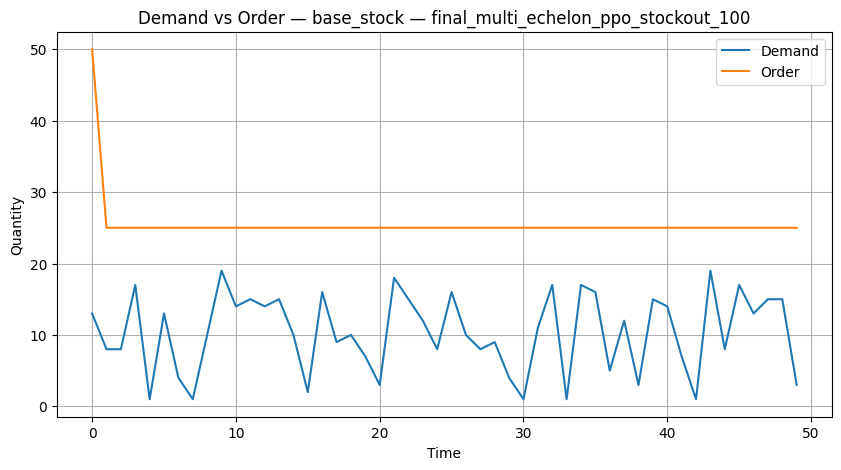

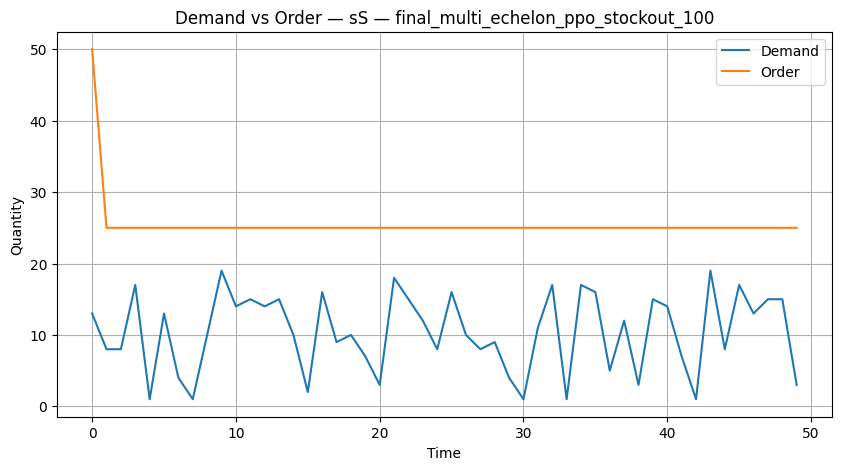

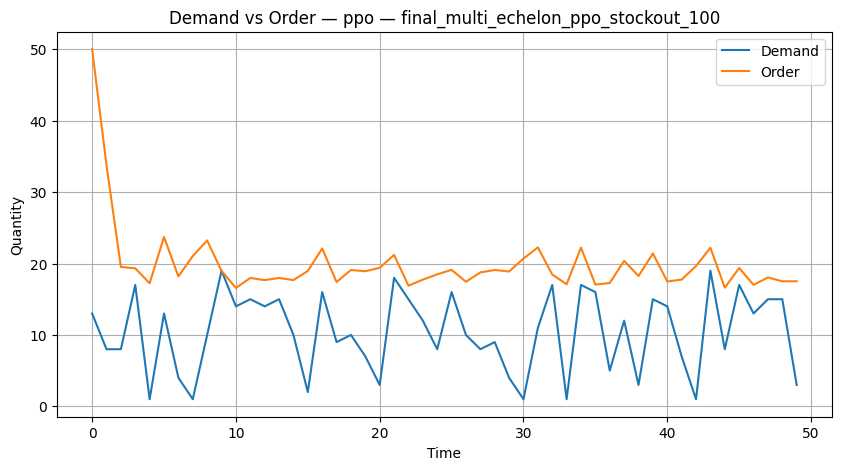

In [6]:
for scenario_id, trajectories in all_trajectories.items():
    for policy_name, df in trajectories.items():
        plot_demand_vs_order(
            df,
            title=f"Demand vs Order — {policy_name} — {scenario_id}"
        )